Visualization of the success of the derived features (FE), the rationality of WoE/IV filtering, and the "Importance" (Gain/Shap) scores assigned to these features by the models.

# **STAGE 3**

In [63]:
import sys
import os
import importlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb

sys.path.append(os.path.abspath("../scripts"))

try:
    import config
    importlib.reload(config)
    from config import STAGE1_OUT, VAL_SPLIT_DATE

    import data_loader
    importlib.reload(data_loader)

    import feature_engineering
    importlib.reload(feature_engineering)

    from utils import validation
    importlib.reload(validation)

    import utils.plotting as plotting
    importlib.reload(plotting)
    plotting.set_style()

    print("Success: All modules and atomic functions reloaded.")
except Exception as e:
    print(f"Error during manual reload: {e}")

plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

Success: All modules and atomic functions reloaded.


In [44]:
sub_train = pd.read_parquet(STAGE1_OUT / "train_base.parquet")
sub_val = pd.read_parquet(STAGE1_OUT / "val_base.parquet")
test_fe = pd.read_parquet(STAGE1_OUT / "test_base.parquet")

print(f"Initial Shapes -> Train: {sub_train.shape}, Val: {sub_val.shape}, Test: {test_fe.shape}")
display(sub_train.head(3))

Initial Shapes -> Train: (179080, 40), Val: (20920, 40), Test: (80000, 39)


,appointment_id,patient_id,clinic_id,specialty,appointment_datetime,booking_datetime,lead_time_hours,appointment_dow,appointment_hour,is_weekend,...,area_id,specialty_clinic,clinic_lat,clinic_lon,capacity_daily,base_wait_mins_est,open_on_saturday,sms_policy_prob,is_cold_start_clinic,sms_is_missing
0,2,17714,1,gynecology,2025-04-07 12:15:00,2025-03-28 22:26:39,229.805649,0,12,0,...,5,gynecology,39.950367,32.866608,89,22.465481,0,0.419637,0,0
1,4,4986,19,orthopedics,2025-07-17 16:45:00,2025-07-15 03:15:37,61.489704,3,16,0,...,119,orthopedics,39.845600,32.841854,81,27.688885,0,0.484473,0,1
2,5,1874,18,cardiology,2025-04-22 10:30:00,2025-03-22 23:56:40,730.555481,1,10,0,...,5,cardiology,40.103737,32.834515,81,30.246033,1,0.641033,0,1


In [45]:
# Check for missing values before FE
data_loader.check_missing_values(sub_train, "Sub-Train Base")
data_loader.check_missing_values(test_fe, "Test Base")

# Technical Note: age_bucket fails if age=0 is not handled or NaNs exist.
print(f"Unique age values (min/max): {sub_train['age'].min()} / {sub_train['age'].max()}")

Missing values found in Sub-Train Base:
                Missing Values  % of Total Values
sms_lead_hours           11581           6.466942
Missing values found in Test Base:
                Missing Values  % of Total Values
sms_lead_hours            5199            6.49875
Unique age values (min/max): 0 / 90


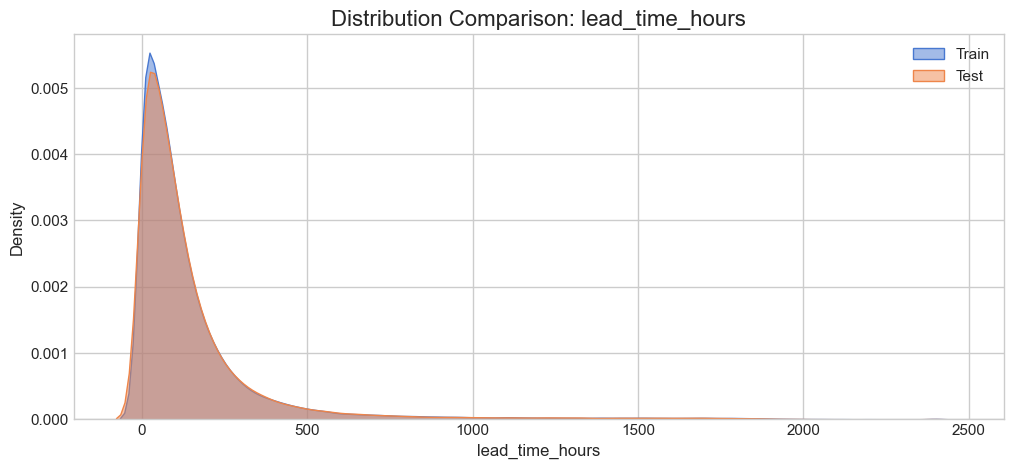

In [46]:
plotting.plot_distribution_comparison(sub_train, test_fe, 'lead_time_hours')

In [47]:
for df in [sub_train, sub_val, test_fe]:
    df = feature_engineering.create_temporal_features(df)

print(f"Post-Temporal Shape: {sub_train.shape}")
print("New temporal columns:", [c for c in sub_train.columns if 'sin' in c or 'cos' in c])

Post-Temporal Shape: (179080, 46)
New temporal columns: ['sms_is_missing', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos']


In [48]:
# Patient behavioral history
sub_train = feature_engineering.create_patient_history_aggregations(sub_train)
sub_val = feature_engineering.create_patient_history_aggregations(sub_val)
test_fe = feature_engineering.create_patient_history_aggregations(test_fe)

print(f"Post-History Shape: {sub_train.shape}")
display(sub_train[['patient_id', 'patient_appt_count', 'patient_avg_lead_time']].tail(5))

Post-History Shape: (179080, 50)


,patient_id,patient_appt_count,patient_avg_lead_time
14440,29999,4,146.811415
128147,29999,5,119.435640
49279,29999,6,104.948578
108940,30000,0,0.000000
33863,30000,1,20.792530


In [49]:
# Clinic dynamic load
sub_train = feature_engineering.create_clinic_load_aggregations(sub_train)
sub_val = feature_engineering.create_clinic_load_aggregations(sub_val)
test_fe = feature_engineering.create_clinic_load_aggregations(test_fe)

print(f"Post-Clinic Dynamics Shape: {sub_train.shape}")
display(sub_train[['clinic_id', 'clinic_load_avg_7d', 'clinic_load_max_7d']].head(5))

Post-Clinic Dynamics Shape: (179080, 53)


,clinic_id,clinic_load_avg_7d,clinic_load_max_7d
0,1,45.285714,65.0
1,13,23.000000,33.0
2,28,48.142857,64.0
3,21,25.142857,34.0
4,23,23.571429,31.0


In [50]:
# Hierarchical encoding using Sub-Train as reference to avoid leakage
sub_val = feature_engineering.apply_hierarchical_clinic_encoding(sub_train, sub_val)
test_fe = feature_engineering.apply_hierarchical_clinic_encoding(sub_train, test_fe)

# Manual prior for sub_train consistency
sub_train['hier_score'] = sub_train['label_noshow'] 

print(f"Post-Hierarchical Shape (Val): {sub_val.shape}")
print(f"Hier_score check (mean): {sub_val['hier_score'].mean():.4f}")

Post-Hierarchical Shape (Val): (20920, 54)
Hier_score check (mean): 0.2390


c:\Users\Eren\Desktop\data_league_26\scripts\utils\plotting.py:68: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cat_col, y=target_col, data=df, order=order, palette='magma', errorbar=None)


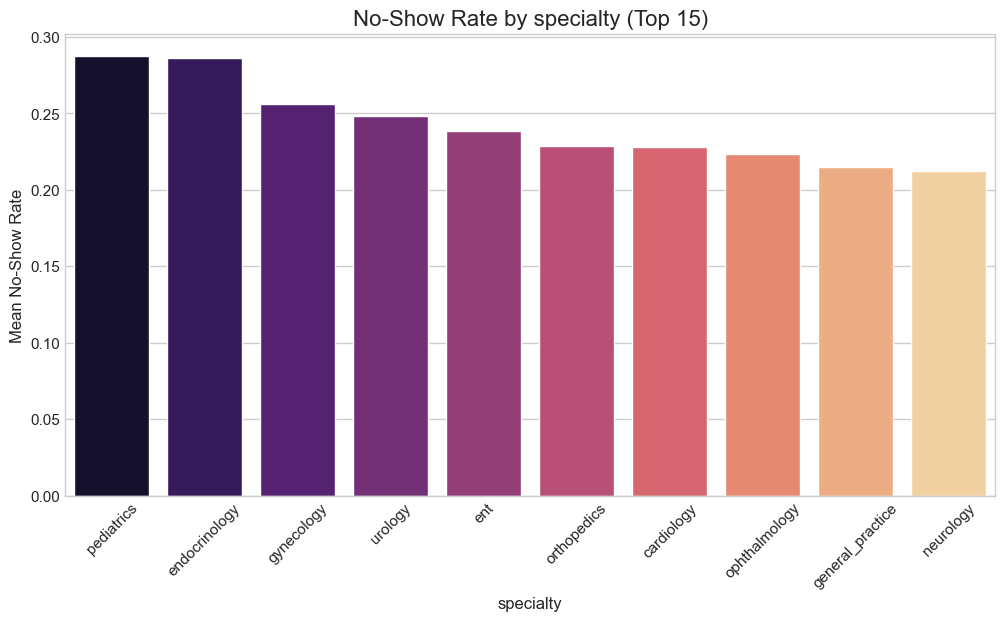

In [51]:
plotting.plot_categorical_noshow_rate(sub_train, 'specialty')

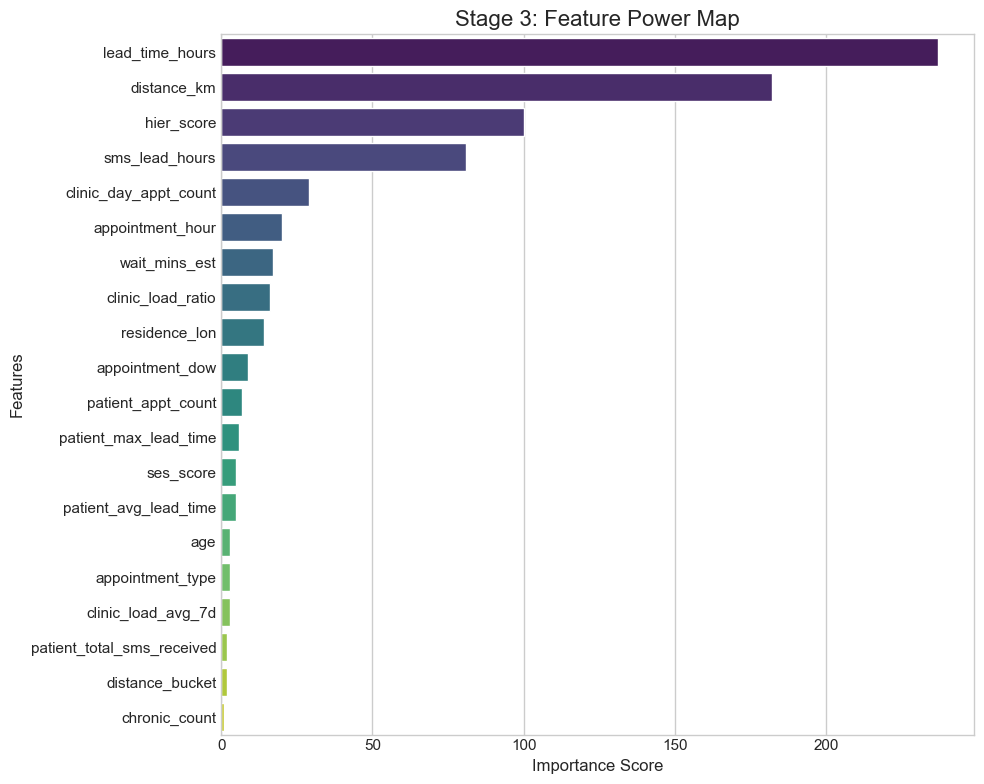

In [ ]:
import lightgbm as lgb

cat_cols = ['booking_channel', 'appointment_type', 'sex', 'specialty_clinic']

for col in cat_cols:
    if col in sub_train.columns:
        sub_train[col] = sub_train[col].astype('category')
        sub_val[col] = sub_val[col].astype('category')

drop_cols = [
    'appointment_id', 'patient_id', 'clinic_id', 
    'appointment_datetime', 'booking_datetime', 
    'label_noshow', 'specialty', 'area_id', 'age_bucket'
]

features = [c for c in sub_train.columns if c not in drop_cols] 

diag_model = lgb.LGBMClassifier(n_estimators=100, random_state=42, verbose=-1)
diag_model.fit(sub_train[features], sub_train['label_noshow'])

importance_df = pd.DataFrame({
    'feature': features,
    'importance': diag_model.feature_importances_
}).sort_values(by='importance', ascending=False)

# 7. Visualize
plotting.plot_feature_importance(importance_df, title="Stage 3: Feature Power Map")

In [52]:
# Apply demographic proxy based on age_bucket, area, and ses_score
sub_val = feature_engineering.apply_patient_demographic_proxy(sub_train, sub_val)
test_fe = feature_engineering.apply_patient_demographic_proxy(sub_train, test_fe)

# Defensive check for age_bucket conversion
print(f"Age Bucket distribution in Val:\n{sub_val['age_bucket'].value_counts()}")
print(f"Post-Proxy Shape: {sub_val.shape}")

Age Bucket distribution in Val:
age_bucket
5    4966
3    4654
2    4327
4    3913
1    3060
Name: count, dtype: int64
Post-Proxy Shape: (20920, 56)


In [53]:
# Applying the Expansion
print(f"Original shape: {sub_train.shape}")

Original shape: (179080, 55)


In [54]:
print(f"Base shape: {sub_train.shape}")

for df in [sub_train, sub_val, test_fe]:
    df = feature_engineering.create_advanced_interactions(df)

print(f"Shape after Phase 1 (Interactions): {sub_train.shape}")

Base shape: (179080, 55)
Shape after Phase 1 (Interactions): (179080, 60)


In [55]:
sub_val = feature_engineering.apply_multi_level_target_encoding(sub_train, sub_val)
test_fe = feature_engineering.apply_multi_level_target_encoding(sub_train, test_fe)

# Apply to sub_train using its own stats for consistent feature space
sub_train = feature_engineering.apply_multi_level_target_encoding(sub_train, sub_train)

print(f"Sub-train: {sub_train.shape}")
print(f"New TE columns: {[c for c in sub_train.columns if c.startswith('te_')]}")

Sub-train: (179080, 65)
New TE columns: ['te_specialty_day_of_week', 'te_area_id_day_of_week', 'te_specialty_hour', 'te_booking_channel_appointment_type', 'te_sex_specialty']


In [ ]:
# (STD, MAX, Diversity)
sub_train = feature_engineering.create_deep_aggregations(sub_train)
sub_val = feature_engineering.create_deep_aggregations(sub_val)
test_fe = feature_engineering.create_deep_aggregations(test_fe)

print(f"Sub-train: {sub_train.shape}")

Sub-train: (179080, 74)


In [57]:
# Automated expansion via Frequency Counting
sub_train = feature_engineering.generate_bulk_features(sub_train)
sub_val = feature_engineering.generate_bulk_features(sub_val)
test_fe = feature_engineering.generate_bulk_features(test_fe)

print(f"Final Expanded shape: {sub_train.shape}")
display(sub_train.tail(3))

Final Expanded shape: (179080, 79)


,appointment_id,patient_id,clinic_id,specialty,appointment_datetime,booking_datetime,lead_time_hours,appointment_dow,appointment_hour,is_weekend,...,clinic_age_std,clinic_distance_km_mean,pt_spec_nunique,pt_clinic_nunique,pt_area_nunique,specialty_count_freq,clinic_id_count_freq,area_id_count_freq,patient_id_count_freq,hour_count_freq
179077,55149,29999,7,general_practice,2025-06-25 14:00:00,2025-06-23 00:51:24,61.143291,2,14,0,...,22.900779,15.643896,6,7,1,54041,13302,3368,7,8172
179078,121715,30000,1,gynecology,2025-03-07 12:15:00,2025-03-06 15:27:26,20.792530,4,12,0,...,22.990101,13.181166,2,2,1,34487,10060,3094,2,67171
179079,37891,30000,22,general_practice,2025-06-19 10:30:00,2025-06-16 12:48:49,69.686249,3,10,0,...,23.221891,15.189837,2,2,1,54041,8685,3094,2,17923


In [78]:
importlib.reload(config)
from config import STAGE3_OUT

# Ensure directory exists
STAGE3_OUT.mkdir(parents=True, exist_ok=True)

print(f"Saving 'Golden' (79-feature) datasets to: {STAGE3_OUT}")

# Downcast to save space before snapshot
sub_train_79 = data_loader.downcast_memory(sub_train)
sub_val_79 = data_loader.downcast_memory(sub_val)
test_fe_79 = data_loader.downcast_memory(test_fe)

# Save as separate 'golden' files
sub_train_79.to_parquet(STAGE3_OUT / "train_golden_79.parquet", index=False)
sub_val_79.to_parquet(STAGE3_OUT / "val_golden_79.parquet", index=False)
test_fe_79.to_parquet(STAGE3_OUT / "test_golden_79.parquet", index=False)

print(f"Success: 79-feature 'Golden Set' is now persistent.")
print(f"Final Column Count: {len(sub_train_79.columns)}")

Saving 'Golden' (79-feature) datasets to: C:\Users\Eren\Desktop\data_league_26\processed_data\stage3
Success: 79-feature 'Golden Set' is now persistent.
Final Column Count: 79


In [ ]:
print(f"Starting expansion. Current shape: {sub_train.shape}")

# Sıralama: Önce Train'i genişlet, sonra Val ve Test'i Train üzerinden genişlet
sub_train_final = feature_engineering.expand_to_150_plus(sub_train, sub_train)
sub_val_final = feature_engineering.expand_to_150_plus(sub_train, sub_val)
test_fe_final = feature_engineering.expand_to_150_plus(sub_train, test_fe)

print(f"Final Exploded Shapes:")
print(f"Train: {sub_train_final.shape}")
print(f"Val: {sub_val_final.shape}")
print(f"Test: {test_fe_final.shape}")

Starting expansion. Current shape: (179080, 79)
Final Exploded Shapes:
Train: (179080, 166)
Val: (20920, 167)
Test: (80000, 166)


In [77]:
import config
import importlib
importlib.reload(config)
from config import STAGE3_OUT

STAGE3_OUT.mkdir(parents=True, exist_ok=True)

print(f"Saving 167-feature datasets to: {STAGE3_OUT}")

sub_train_final = data_loader.downcast_memory(sub_train_final)
sub_val_final = data_loader.downcast_memory(sub_val_final)
test_fe_final = data_loader.downcast_memory(test_fe_final)

# Parquet Export
sub_train_final.to_parquet(STAGE3_OUT / "train_exploded_167.parquet", index=False)
sub_val_final.to_parquet(STAGE3_OUT / "val_exploded_167.parquet", index=False)
test_fe_final.to_parquet(STAGE3_OUT / "test_exploded_167.parquet", index=False)

print(f"Checkpoint reached: Stage 3 data is now persistent on disk.")
print(f"Final Column Count: {len(sub_train_final.columns)}")

Saving 167-feature datasets to: C:\Users\Eren\Desktop\data_league_26\processed_data\stage3
Checkpoint reached: Stage 3 data is now persistent on disk.
Final Column Count: 167


# **STAGE 4**

# **STAGE 5**